In [ ]:
#Week 7 - 4 
#Bolortulga Seded
#24 March 2026
#Naive bayes practical 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline


In [3]:
col_names = ['age', 'workclass', 'fnlwgt', 'education', 'education_num',
             'marital_status', 'occupation', 'relationship', 'race', 'sex',
             'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income']

df = pd.read_csv("adult (1).csv", header=None, names=col_names, sep=',\s', engine='python')

df.shape

(32561, 15)

In [4]:
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [5]:
categorical = [var for var in df.columns if df[var].dtype=='0']
numerical = [var for var in df.columns if df[var].dtype != '0']
print('Categorical variables:', categorical)
print('Numerical variables:', numerical)

Categorical variables: []
Numerical variables: ['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income']


In [7]:
df['workclass'].replace('?', np.nan, inplace=True)
df['occupation'].replace('?', np.nan, inplace=True)
df['native_country'].replace('?', np.nan, inplace=True)

df[categorical].isnull().sum()

Series([], dtype: float64)

In [8]:
X = df.drop(['income'], axis=1)
y = df['income']

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
X_train.shape, X_test.shape

((22792, 14), (9769, 14))

In [10]:
for dataset in [X_train, X_test]:
    dataset['workclass'].fillna(X_train['workclass'].mode()[0], inplace=True)
    dataset['occupation'].fillna(X_train['occupation'].mode()[0], inplace=True)
    dataset['native_country'].fillna(X_train['native_country'].mode()[0], inplace=True)

X_train.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
dtype: int64

In [12]:
import category_encoders as ce

encoder = ce.OneHotEncoder(cols=['workclass', 'education', 'marital_status', 'occupation',
                                  'relationship', 'race', 'sex', 'native_country'])

X_train = encoder.fit_transform(X_train)
X_test  = encoder.transform(X_test)

X_train.shape

(22792, 108)

In [13]:
from sklearn.preprocessing import RobustScaler

cols = X_train.columns
scaler = RobustScaler()

X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=cols)
X_test  = pd.DataFrame(scaler.transform(X_test),      columns=cols)

X_train.head()

,age,workclass_1,workclass_2,workclass_3,workclass_4,workclass_5,workclass_6,workclass_7,workclass_8,workclass_9,...,native_country_33,native_country_34,native_country_35,native_country_36,native_country_37,native_country_38,native_country_39,native_country_40,native_country_41,native_country_42
0,0.40,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.50,-1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.55,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-0.40,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-0.70,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [14]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()
gnb.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [15]:
from sklearn.metrics import accuracy_score

y_pred = gnb.predict(X_test)

print('Test  accuracy: {:.4f}'.format(accuracy_score(y_test, y_pred)))
print('Train accuracy: {:.4f}'.format(accuracy_score(y_train, gnb.predict(X_train))))

Test  accuracy: 0.7973
Train accuracy: 0.8000


Confusion Matrix:
 [[5871 1536]
 [ 444 1918]]


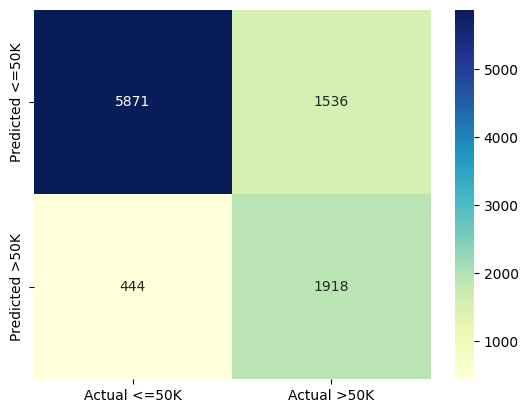

In [16]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:\n', cm)

cm_df = pd.DataFrame(cm,
                     columns=['Actual <=50K', 'Actual >50K'],
                     index=['Predicted <=50K', 'Predicted >50K'])
sns.heatmap(cm_df, annot=True, fmt='d', cmap='YlGnBu')
plt.show()

In [17]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       <=50K       0.93      0.79      0.86      7407
        >50K       0.56      0.81      0.66      2362

    accuracy                           0.80      9769
   macro avg       0.74      0.80      0.76      9769
weighted avg       0.84      0.80      0.81      9769



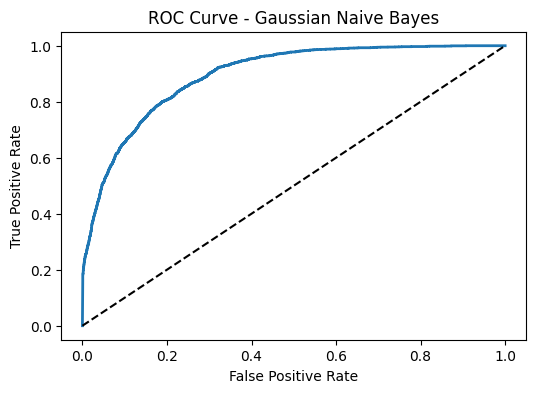

ROC AUC: 0.8943


In [18]:
from sklearn.metrics import roc_curve, roc_auc_score

y_pred_prob = gnb.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_pred_prob, pos_label='>50K')

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, linewidth=2)
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve - Gaussian Naive Bayes')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()

print('ROC AUC: {:.4f}'.format(roc_auc_score(y_test, y_pred_prob)))

In [19]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(gnb, X_train, y_train, cv=10, scoring='accuracy')

print('CV scores:        ', scores)
print('Mean CV accuracy: {:.4f}'.format(scores.mean()))

CV scores:         [0.80526316 0.79824561 0.8056165  0.80254498 0.79245283 0.79245283
 0.79991224 0.80649408 0.79245283 0.80254498]
Mean CV accuracy: 0.7998
